# 08 — Multi-Grating Nitrogen Abundances (Berg+25 method)

**Purpose:** Replicate the nitrogen abundance methodology of
[Berg et al. (2025)](https://arxiv.org/abs/2511.13591) for the lensed
galaxy RXCJ2248-ID3 (source 2478_3, z ~ 6.1) using three NIRSpec
medium-resolution grating spectra.

### Methodology (following Berg+25)

1. **Dust correction** from Hgamma/Hbeta Balmer decrement (Cardelli+89)
2. **Multi-phase electron density** from 5 diagnostics:
   - N IV] 1483/1487 -> n_e(N3+) -- high-ionisation UV
   - C III] 1907/1909 -> n_e(C2+) -- intermediate UV
   - Si III] 1883/1892 -> n_e(Si2+) -- intermediate UV
   - [Ar IV] 4713/4741 -> n_e(Ar3+) -- high-ionisation optical
   - [S II] 6718/6732 -> n_e(S+) -- low-ionisation optical
3. **Electron temperature** from [O III] 4363/5007 + Garnett (1992)
   Te-Te relations for 3 ionisation zones
4. **Ionic abundances** with zone-specific Te/ne
5. **Four N/O methods** (Berg+25 Eqs. 2-5):
   - Method 1: N+/O+
   - Method 2: N2+/O2+
   - Method 3: N3+/O2+
   - Method 4: (N+ + N2+ + N3+) / (O+ + O2+)

| Grating | Coverage (um) | N lines | Density diagnostics |
|---------|---------------|---------|---------------------|
| G140M   | 0.97-1.87     | NIV] 1483/1487, NIII] 1749/1752 | NIV], CIII], SiIII] |
| G235M   | 1.66-3.17     | --      | [OII] 3726/3729 |
| G395M   | 2.87-5.27     | [NII] 5756, 6549, 6585 | [ArIV], [SII] |

**Date:** 2026-02-19

In [1]:
import jwspecfit
from jwspecfit.lines import REST_LINES_A
from jwspecabund.dust import cardelli_extinction, compute_Av_from_balmer
from jwspecabund.forward import hbeta_emissivity_aller84
import matplotlib.pyplot as plt
import numpy as np
import pyneb as pn

z = 6.1052

print(f"jwspecfit  v{jwspecfit.__version__}")
print(f"pyneb     v{pn.__version__}")

jwspecfit  v0.1.0
pyneb     v1.1.28


## 1. Load the three grating spectra

In [2]:
spec_g140m = jwspecfit.read_fits(
    "../../data/stark-rxcj2248-v4_g140m-f100lp_2478_3.spec.fits", z=z,
)
spec_g235m = jwspecfit.read_fits(
    "../../data/stark-rxcj2248-v4_g235m-f170lp_2478_3.spec.fits", z=z,
)
spec_g395m = jwspecfit.read_fits(
    "../../data/stark-rxcj2248-v4_g395m-f290lp_2478_3.spec.fits", z=z,
)

for name, spec in [("G140M", spec_g140m), ("G235M", spec_g235m), ("G395M", spec_g395m)]:
    v = spec.mask_valid()
    print(f"{name}: {spec.n_pix} px, {spec.wave_um[v].min():.3f}-{spec.wave_um[v].max():.3f} um")

G140M: 4667 px, 0.957-2.734 um
G235M: 3685 px, 1.605-4.574 um
G395M: 1661 px, 2.685-5.500 um


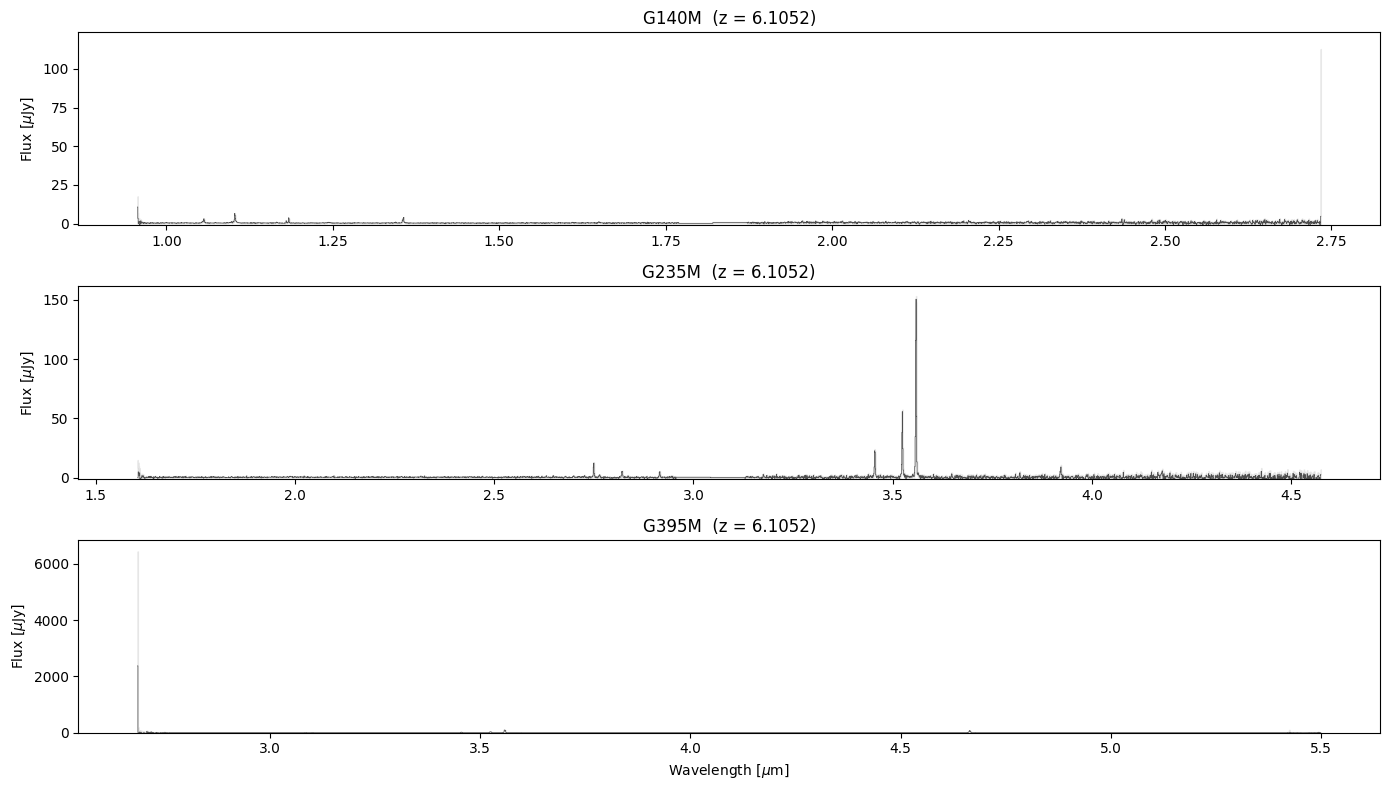

In [3]:
fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=False)

for ax, (name, spec) in zip(axes, [("G140M", spec_g140m), ("G235M", spec_g235m), ("G395M", spec_g395m)]):
    v = spec.mask_valid()
    ax.step(spec.wave_um[v], spec.flux_ujy[v], where="mid", lw=0.5, color="0.3")
    ax.fill_between(
        spec.wave_um[v],
        (spec.flux_ujy - spec.err_ujy)[v],
        (spec.flux_ujy + spec.err_ujy)[v],
        step="mid", alpha=0.15, color="0.5",
    )
    ax.set_ylabel(r"Flux [$\mu$Jy]")
    ax.set_title(f"{name}  (z = {z})")
    ax.set_ylim(-1, None)

axes[-1].set_xlabel(r"Wavelength [$\mu$m]")
plt.tight_layout()

## 2. Fit G395M -- optical lines

Expanded line list: add [Ar IV] 4713/4741 (density diagnostic),
He II 4687 (y2+), and He I 4472.

In [4]:
# Expanded G395M line list: add diagnostics not in the default grating list
g395m_lines = jwspecfit.lines.get_line_list("g395m") + [
    "HeI_4472",
    "HeII_4687",
    "ArIV_4713",
    "ArIV_4741",
]

print("G395M lines to fit:")
for name in g395m_lines:
    obs_um = REST_LINES_A[name] * (1 + z) * 1e-4
    print(f"  {name:<16s}  rest {REST_LINES_A[name]:.1f} A  ->  obs {obs_um:.4f} um")

G395M lines to fit:
  OII_3726          rest 3727.1 A  ->  obs 2.6482 um
  OII_3729          rest 3729.9 A  ->  obs 2.6502 um
  HDELTA            rest 4104.0 A  ->  obs 2.9160 um
  HGAMMA            rest 4342.9 A  ->  obs 3.0857 um
  OIII_4363         rest 4364.4 A  ->  obs 3.1010 um
  HBETA             rest 4864.0 A  ->  obs 3.4560 um
  OIII_4959         rest 4961.7 A  ->  obs 3.5254 um
  OIII_5007         rest 5009.6 A  ->  obs 3.5594 um
  NII_5756          rest 5757.8 A  ->  obs 4.0910 um
  HEI_5877          rest 5878.9 A  ->  obs 4.1771 um
  NII_6549          rest 6551.7 A  ->  obs 4.6551 um
  Ha                rest 6566.4 A  ->  obs 4.6656 um
  NII_6585          rest 6587.1 A  ->  obs 4.6803 um
  SII_6718          rest 6720.1 A  ->  obs 4.7748 um
  SII_6732          rest 6734.5 A  ->  obs 4.7850 um
  HeI_4472          rest 4472.7 A  ->  obs 3.1780 um
  HeII_4687         rest 4687.0 A  ->  obs 3.3302 um
  ArIV_4713         rest 4712.6 A  ->  obs 3.3484 um
  ArIV_4741         rest 4

In [5]:
result_g395m = jwspecfit.fit_lines(spec_g395m, z=z, deg=3, n_boot=1000, lines=g395m_lines,mode='off')

print(f"Lines fitted: {len(result_g395m.lines)}")
print(f"chi2/dof:     {result_g395m.chi2:.2f}")
print()
print(f"{'Line':<18s} {'Flux':>12s} {'Err':>12s} {'SNR':>8s}")
print("-" * 52)
for name, lr in result_g395m.lines.items():
    tag = " *" if "BROAD" in name else ""
    print(f"{name + tag:<18s} {lr.flux:12.3e} {lr.flux_err:12.3e} {lr.snr:8.1f}")

Bootstrap: 100%|██████████| 1000/1000 [00:56<00:00, 17.66iter/s]

Lines fitted: 17
chi2/dof:     1.18

Line                       Flux          Err      SNR
----------------------------------------------------
HDELTA                3.756e-18    5.325e-19      7.1
HGAMMA                7.950e-18    7.417e-19     10.7
OIII_4363             6.092e-18    1.313e-18      4.6
HBETA                 1.721e-17    1.105e-18     15.6
OIII_4959             3.000e-17    1.505e-18     19.9
OIII_5007             8.796e-17    1.325e-18     66.4
NII_5756              3.824e-19    2.652e-19      1.4
HEI_5877              2.827e-18    5.130e-19      5.5
NII_6549              1.352e-18    1.579e-19      8.6
Ha                    4.211e-17    1.951e-18     21.6
NII_6585              4.002e-18    4.674e-19      8.6
SII_6718              7.758e-20    3.013e-19      0.3
SII_6732              4.629e-29    1.909e-19      0.0
HeI_4472              9.100e-19    3.539e-19      2.6
HeII_4687             5.281e-19    3.528e-19      1.5
ArIV_4713             3.615e-19    2.720e-19  

/Users/raunaqrai/miniforge3/envs/jwst/lib/python3.12/site-packages/jwspecfit/plotting.py:309: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


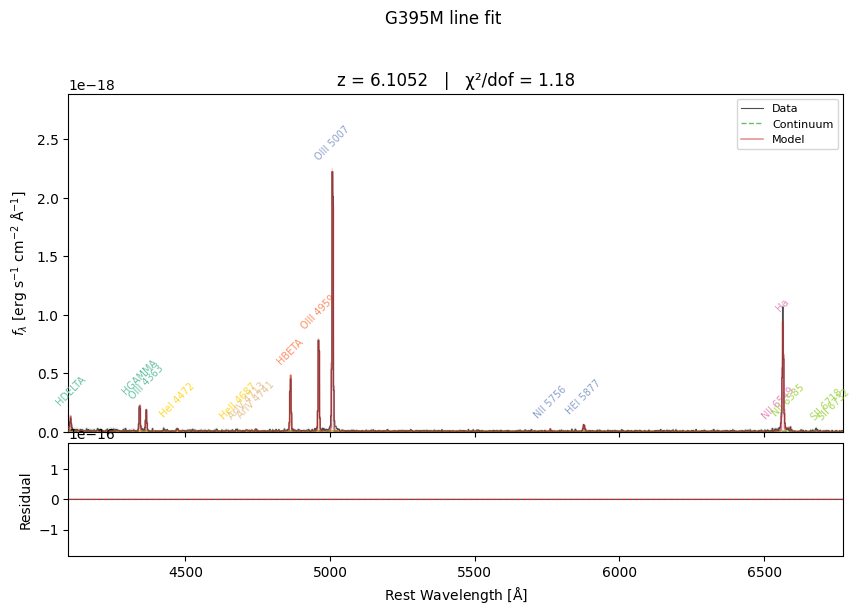

In [6]:
fig = jwspecfit.plot_fit(result_g395m, flux_unit='flam',rest_frame=True)
fig.suptitle("G395M line fit", y=1.02)
plt.show()

In [7]:
fig_interactive = jwspecfit.plot_fit_interactive(result_g395m,flux_unit="flam",rest_frame=True)
fig_interactive.show()

## 3. Fit G235M -- [OII] doublet, [OIII] 4363

In [7]:
# G235M: auto-detect lines from grating; mode="off" skips broad search
# (G395M handles broad Balmer fitting at higher SNR)
result_g235m = jwspecfit.fit_lines(
    spec_g235m, z=z, grating="g235m", deg=3, n_boot=1000, mode="off",
)

print(f"Lines fitted: {len(result_g235m.lines)}")
print(f"chi2/dof:     {result_g235m.chi2:.2f}")
print()
print(f"{'Line':<18s} {'Flux':>12s} {'Err':>12s} {'SNR':>8s}")
print("-" * 52)
for name, lr in result_g235m.lines.items():
    print(f"{name:<18s} {lr.flux:12.3e} {lr.flux_err:12.3e} {lr.snr:8.1f}")

Bootstrap: 100%|██████████| 1000/1000 [00:29<00:00, 33.88iter/s]

Lines fitted: 8
chi2/dof:     1.03

Line                       Flux          Err      SNR
----------------------------------------------------
OII_3726              7.395e-19    3.999e-19      1.8
OII_3729              4.506e-19    5.386e-19      0.8
HDELTA                4.110e-18    4.053e-19     10.1
HBETA                 1.546e-17    6.018e-19     25.7
OIII_4959             3.313e-17    8.089e-19     41.0
OIII_5007             8.791e-17    1.041e-18     84.5
NII_5756              6.395e-19    7.183e-19      0.9
HEI_5877              5.658e-18    1.381e-18      4.1


/Users/raunaqrai/miniforge3/envs/jwst/lib/python3.12/site-packages/jwspecfit/plotting.py:298: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



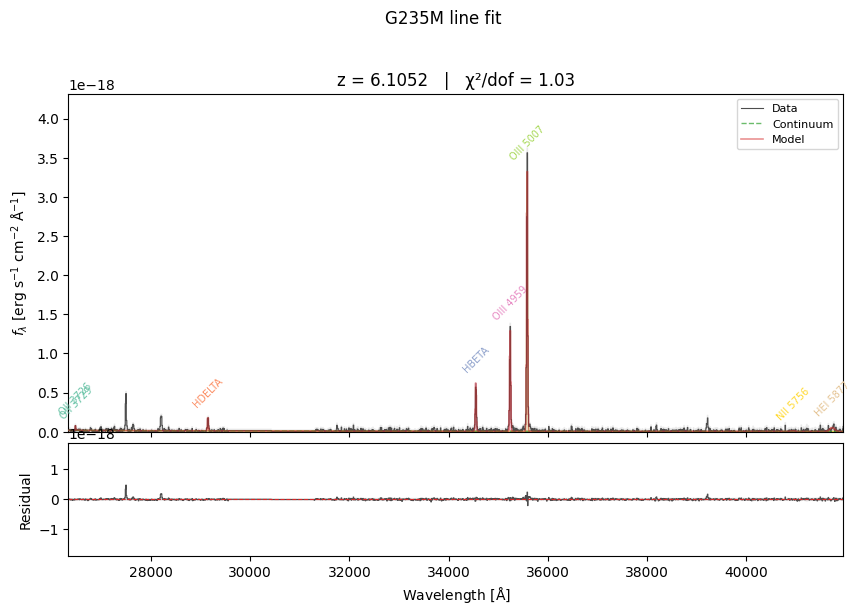

In [32]:
fig = jwspecfit.plot_fit(result_g235m,flux_unit='flam')
fig.suptitle("G235M line fit", y=1.02)
plt.show()

## 4. Fit G140M -- UV lines

Custom line list including both components of the NIV], CIII], and
SiIII] doublets (needed for density diagnostics), plus NIII] for
N2+ abundance.

In [ ]:
# UV candidates -- include both doublet components for density diagnostics
g140m_lines = [
    "NIV_1483", "NIV_1",         # N IV] doublet (density + N3+ abundance)
    "CIV_1", "CIV_2",            # C IV doublet
    "HEII_1640",                  # He II 1640
    "OIII_1661", "OIII_1666",    # [O III] 1661/1666 doublet (resolved)
    "NIII_1749", "NIII_1752",     # N III] doublet (N2+ abundance)
    "SiIII_1", "SiIII_2",        # Si III] doublet (density)
    "CIII]_1907", "CIII]",        # C III] doublet (density + C2+ abundance)
]

print("G140M lines to fit:")
for name in g140m_lines:
    obs_um = REST_LINES_A[name] * (1 + z) * 1e-4
    print(f"  {name:<16s}  rest {REST_LINES_A[name]:.1f} A  ->  obs {obs_um:.4f} um")

In [10]:
# mode="off" -- UV lines have no Balmer components for broad detection
result_g140m = jwspecfit.fit_lines(
    spec_g140m, z=z, deg=3, n_boot=1000,
    lines=g140m_lines, mode="off",
)

print(f"Lines fitted: {len(result_g140m.lines)}")
print(f"chi2/dof:     {result_g140m.chi2:.2f}")
print()
print(f"{'Line':<18s} {'Flux':>12s} {'Err':>12s} {'SNR':>8s}")
print("-" * 52)
for name, lr in result_g140m.lines.items():
    print(f"{name:<18s} {lr.flux:12.3e} {lr.flux_err:12.3e} {lr.snr:8.1f}")

Bootstrap: 100%|██████████| 1000/1000 [01:43<00:00,  9.70iter/s]

Lines fitted: 12
chi2/dof:     1.22

Line                       Flux          Err      SNR
----------------------------------------------------
NIV_1483              4.437e-18    5.746e-19      7.7
NIV_1                 1.136e-17    5.626e-19     20.2
CIV_1                 4.970e-18    5.522e-19      9.0
CIV_2                 2.854e-17    7.738e-19     36.9
HEII_1640             2.385e-18    4.275e-19      5.6
OIII_1663             8.198e-18    5.072e-19     16.2
NIII_1749             1.098e-18    8.015e-19      1.4
NIII_1752             2.641e-18    7.656e-19      3.4
SiIII_1               6.163e-19    2.474e-19      2.5
SiIII_2               1.735e-18    4.816e-19      3.6
CIII]_1907            4.234e-18    2.827e-18      1.5
CIII]                 7.581e-18    2.231e-18      3.4


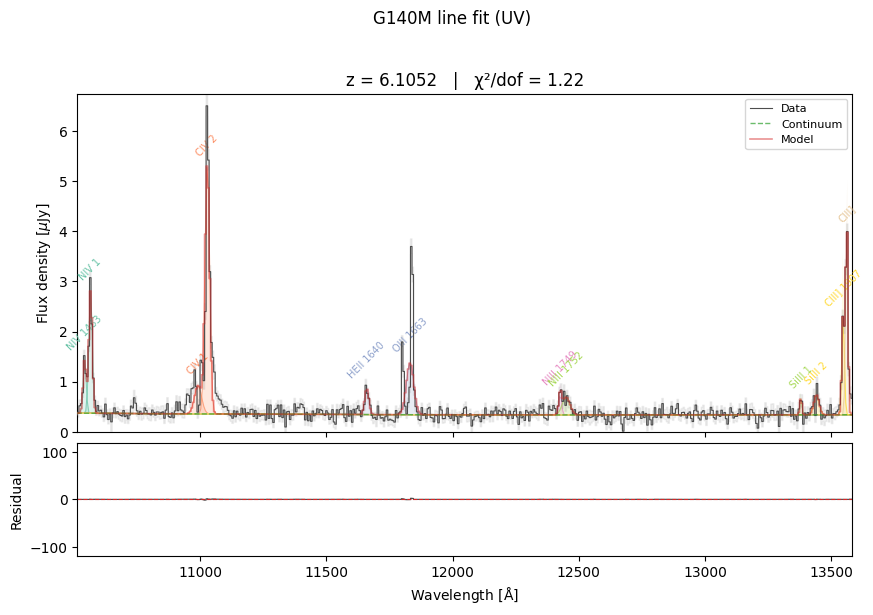

In [11]:
fig = jwspecfit.plot_fit(result_g140m)
fig.suptitle("G140M line fit (UV)", y=1.02)
plt.show()

## 5. Cross-grating calibration check

[OIII] 4363 falls in the overlap region between G235M and G395M.
Compare the measured flux in both gratings.

In [12]:
def get_flux(result, name):
    """Return (flux, flux_err) for a line, or (nan, nan) if missing."""
    lr = result.lines.get(name)
    if lr is None:
        return np.nan, np.nan
    return lr.flux, lr.flux_err

print("Cross-grating flux comparison:")
print(f"{'Line':<18s} {'G235M':>14s} {'G395M':>14s} {'Ratio':>10s}")
print("-" * 58)
for name in result_g235m.lines:
    if name in result_g395m.lines:
        f235 = result_g235m.lines[name].flux
        f395 = result_g395m.lines[name].flux
        ratio = f235 / f395 if f395 > 0 else np.nan
        print(f"{name:<18s} {f235:14.3e} {f395:14.3e} {ratio:10.3f}")

Cross-grating flux comparison:
Line                        G235M          G395M      Ratio
----------------------------------------------------------
HDELTA                  4.110e-18      3.756e-18      1.094
HBETA                   1.546e-17      1.721e-17      0.898
OIII_4959               3.313e-17      3.000e-17      1.104
OIII_5007               8.791e-17      8.796e-17      0.999
NII_5756                6.395e-19      3.824e-19      1.672
HEI_5877                5.658e-18      2.827e-18      2.001


## 6. Dust correction from Hgamma/Hbeta

Following Berg+25 S2.3: derive E(B-V) from the Hgamma/Hbeta Balmer
decrement using the Cardelli+89 extinction law.  Hgamma/Hbeta is
preferred over Halpha/Hbeta because at extreme densities Halpha can
be enhanced by collisional excitation.

In [13]:
# Get Balmer lines from G395M (sum narrow + broad)
f_Hb, e_Hb = get_flux(result_g395m, "HBETA")
f_Hg, e_Hg = get_flux(result_g395m, "HGAMMA")
f_Ha, e_Ha = get_flux(result_g395m, "Ha")

for bname, base in [("HBETA_BROAD", "Hb"), ("HGAMMA_BROAD", "Hg"), ("Ha_BROAD", "Ha")]:
    lr_broad = result_g395m.lines.get(bname)
    if lr_broad is not None:
        if base == "Hb":
            f_Hb += lr_broad.flux
            e_Hb = np.sqrt(e_Hb**2 + lr_broad.flux_err**2)
        elif base == "Hg":
            f_Hg += lr_broad.flux
            e_Hg = np.sqrt(e_Hg**2 + lr_broad.flux_err**2)
        elif base == "Ha":
            f_Ha += lr_broad.flux
            e_Ha = np.sqrt(e_Ha**2 + lr_broad.flux_err**2)

print(f"Hbeta = {f_Hb:.3e} +/- {e_Hb:.3e}")
print(f"Hgamma = {f_Hg:.3e} +/- {e_Hg:.3e}")
print(f"Halpha = {f_Ha:.3e} +/- {e_Ha:.3e}")
print(f"Observed Hg/Hb = {f_Hg/f_Hb:.3f}  (intrinsic Case B = 0.468)")
print(f"Observed Ha/Hb = {f_Ha/f_Hb:.3f}  (intrinsic Case B = 2.86)")

Hbeta = 1.721e-17 +/- 1.105e-18
Hgamma = 7.950e-18 +/- 7.417e-19
Halpha = 4.211e-17 +/- 1.951e-18
Observed Hg/Hb = 0.462  (intrinsic Case B = 0.468)
Observed Ha/Hb = 2.447  (intrinsic Case B = 2.86)


In [14]:
# Derive A_V from Hgamma/Hbeta using Cardelli law
Av_HgHb, Av_HgHb_err = compute_Av_from_balmer(
    f_Hg, f_Hb, e_Hg, e_Hb,
    law="cardelli",
    intrinsic_ratio=0.468,  # Hg/Hb Case B
    wave_num_A=4342.90,     # Hgamma rest
    wave_den_A=4864.04,     # Hbeta rest
)

Rv = 3.1
EBV = Av_HgHb / Rv
EBV_err = Av_HgHb_err / Rv

print(f"A_V    = {Av_HgHb:.3f} +/- {Av_HgHb_err:.3f} (from Hg/Hb, Cardelli)")
print(f"E(B-V) = {EBV:.3f} +/- {EBV_err:.3f}")
print(f"Berg+25 reports E(B-V) = 0.053 +0.114 -0.053")


A_V    = 0.078 +/- 0.675 (from Hg/Hb, Cardelli)
E(B-V) = 0.025 +/- 0.218
Berg+25 reports E(B-V) = 0.053 +0.114 -0.053


In [15]:
# Dust-correction helper using Cardelli+89
def dust_correct(flux, flux_err, rest_wave_A, Av):
    """Correct a single line flux for dust using Cardelli+89."""
    if Av <= 0 or not np.isfinite(Av):
        return flux, flux_err
    A_lam = cardelli_extinction(np.array([rest_wave_A]), Av)[0]
    factor = 10.0 ** (0.4 * A_lam)
    return flux * factor, flux_err * factor

Av = max(Av_HgHb, 0.0)
print(f"Using A_V = {Av:.3f} for dust correction")

Using A_V = 0.078 for dust correction


## 7. Electron temperature

Te(O2+) from [OIII] 4363/(4959+5007) via PyNEB.  Garnett (1992)
Te-Te relations for three ionisation zones (Berg+25 S4.1).

PyNEB's default Te search grid caps at ~30,000 K; we extend to
100,000 K since this galaxy can be very hot.

In [16]:
O3 = pn.Atom('O', 3)
C3 = pn.Atom('C', 3)
N4_atom = pn.Atom('N', 4)
Si3 = pn.Atom('Si', 3)
Ar4 = pn.Atom('Ar', 4)
H1 = pn.RecAtom('H', 1)

# Dust-corrected [OIII] fluxes from G395M
f_4363, e_4363 = get_flux(result_g395m, "OIII_4363")
f_4959, e_4959 = get_flux(result_g395m, "OIII_4959")
f_5007, e_5007 = get_flux(result_g395m, "OIII_5007")
f_4363_c, _ = dust_correct(f_4363, e_4363, 4364.44, Av)
f_4959_c, _ = dust_correct(f_4959, e_4959, 4961.68, Av)
f_5007_c, _ = dust_correct(f_5007, e_5007, 5009.64, Av)

ratio_oiii = f_4363_c / (f_4959_c + f_5007_c)
print(f"[OIII] 4363 SNR = {f_4363/e_4363:.1f}")
print(f"[OIII] 4363/(4959+5007) = {ratio_oiii:.4f}")


# Garnett (1992) Te-Te relations (Berg+25 S4.1)
def garnett92_Te_int(Te_high):
    """Intermediate zone (O+, C2+, Si2+): Garnett (1992) Eq. 5."""
    t = Te_high / 1e4
    return (0.243 + t * (1.031 - 0.184 * t)) * 1e4

def garnett92_Te_low(Te_high):
    """Low zone (N+, S+): Campbell, Terlevich & Melnick (1986)."""
    t = Te_high / 1e4
    return (0.7 * t + 0.3) * 1e4


# --- Pass 1: Te with ne = 1e4 ---
ne_init = 1e4
Te_high = O3.getTemDen(ratio_oiii, den=ne_init,
                        to_eval="L(4363) / (L(4959) + L(5007))",
                        start_x=3.5, end_x=5.0, log=True)
Te_int = garnett92_Te_int(Te_high)
Te_low = garnett92_Te_low(Te_high)
print(f"\nPass 1 (ne = {ne_init:.0e}):")
print(f"  Te,high = {Te_high:.0f} K")

[OIII] 4363 SNR = 4.6
[OIII] 4363/(4959+5007) = 0.0525

Pass 1 (ne = 1e+04):
  Te,high = 35950 K


## 8. Multi-phase electron density

Five diagnostics spanning low to high ionisation (Berg+25 S4.1,
Table 3).  Each uses a doublet ratio that is sensitive to ne but
insensitive to Te.

| Diagnostic | Ion zone | Te used |
|------------|----------|---------|
| N IV] 1483/1487 | N3+ (high) | Te,high |
| C III] 1907/1909 | C2+ (int) | Te,int |
| Si III] 1883/1892 | Si2+ (int) | Te,int |
| [Ar IV] 4711/4740 | Ar3+ (high) | Te,high |
| [S II] 6718/6732 | S+ (low) | Te,low |

In [17]:
density_results = {}

def try_density(atom, name, result, line1_name, line2_name,
                wave1, wave2, rest1, rest2, Te, min_snr=2.0):
    """Compute ne from a doublet ratio if both lines are detected."""
    f1, e1 = get_flux(result, line1_name)
    f2, e2 = get_flux(result, line2_name)
    snr1 = f1 / e1 if (np.isfinite(e1) and e1 > 0) else 0
    snr2 = f2 / e2 if (np.isfinite(e2) and e2 > 0) else 0

    if snr1 < min_snr or snr2 < min_snr:
        print(f"  {name:<22s}  SNR = {snr1:.1f}, {snr2:.1f}  -- below threshold")
        return np.nan

    f1_c, _ = dust_correct(f1, e1, rest1, Av)
    f2_c, _ = dust_correct(f2, e2, rest2, Av)
    ratio = f1_c / f2_c
    ne_val = atom.getTemDen(ratio, tem=Te, wave1=wave1, wave2=wave2)

    if np.isfinite(ne_val) and ne_val > 0:
        print(f"  {name:<22s}  ratio = {ratio:.3f}  ->  ne = {ne_val:.0f} cm^-3")
        return ne_val
    else:
        print(f"  {name:<22s}  ratio = {ratio:.3f}  (outside physical range)")
        return np.nan

print("--- Density diagnostics (Pass 1) ---")
ne_niv = try_density(N4_atom, "N IV] 1483/1487", result_g140m,
                     "NIV_1483", "NIV_1", 1483, 1487, 1483.32, 1486.50, Te_high)
if np.isfinite(ne_niv):
    density_results["N3+"] = ne_niv

ne_ciii = try_density(C3, "C III] 1907/1909", result_g140m,
                      "CIII]_1907", "CIII]", 1907, 1909, 1906.68, 1908.73, Te_int,
                      min_snr=1.0)
if np.isfinite(ne_ciii):
    density_results["C2+"] = ne_ciii

ne_siiii = try_density(Si3, "Si III] 1883/1892", result_g140m,
                       "SiIII_1", "SiIII_2", 1883, 1892, 1882.71, 1892.03, Te_int)
if np.isfinite(ne_siiii):
    density_results["Si2+"] = ne_siiii

ne_ariv = try_density(Ar4, "[Ar IV] 4711/4740", result_g395m,
                      "ArIV_4713", "ArIV_4741", 4711, 4740, 4712.58, 4741.48, Te_high,
                      min_snr=1.0)
if np.isfinite(ne_ariv):
    density_results["Ar3+"] = ne_ariv

ne_sii_val = try_density(pn.Atom("S", 2), "[S II] 6718/6732", result_g395m,
                         "SII_6718", "SII_6732", 6717, 6731, 6720.15, 6734.53, Te_low)
if np.isfinite(ne_sii_val):
    density_results["S+"] = ne_sii_val


# --- Zone-specific ne assignments (Berg+25 Table 3) ---
ne_fallback = 1e4

# High zone: prefer Ar3+ (less affected by blends), fall back to N3+
ne_high = density_results.get("Ar3+", density_results.get("N3+", ne_fallback))
# Intermediate zone: prefer C2+, fall back to Si2+
ne_int = density_results.get("C2+", density_results.get("Si2+", ne_fallback))
# Low zone: S+ if available
ne_low = density_results.get("S+", ne_fallback)

print(f"\n--- Zone assignments ---")
print(f"  ne,high = {ne_high:.0f} cm^-3  (O2+, N3+, Ar3+)")
print(f"  ne,int  = {ne_int:.0f} cm^-3  (O+, C2+, Si2+, N2+)")
print(f"  ne,low  = {ne_low:.0f} cm^-3  (N+, S+)")


# --- Pass 2: recompute Te with refined high-zone ne ---
Te_high = O3.getTemDen(ratio_oiii, den=ne_high,
                        to_eval="L(4363) / (L(4959) + L(5007))",
                        start_x=3.5, end_x=5.0, log=True)
Te_int = garnett92_Te_int(Te_high)
Te_low = garnett92_Te_low(Te_high)

print(f"\n--- Pass 2 (ne,high = {ne_high:.0f}) ---")
print(f"  Te,high = {Te_high:.0f} K   (O2+, from [OIII] 4363/(4959+5007))")
print(f"  Te,int  = {Te_int:.0f} K  (Garnett 1992)")
print(f"  Te,low  = {Te_low:.0f} K  (Garnett 1992)")
print(f"\nBerg+25: Te = 19,700 K, ne(C2+) = 79,400, ne(N3+) = 265,000")

--- Density diagnostics (Pass 1) ---
  N IV] 1483/1487         ratio = 0.391  ->  ne = 418045 cm^-3
  C III] 1907/1909        ratio = 0.558  ->  ne = 71394 cm^-3
  Si III] 1883/1892       ratio = 0.355  ->  ne = 94841 cm^-3
  [Ar IV] 4711/4740       ratio = 0.803  ->  ne = 9220 cm^-3
  [S II] 6718/6732        SNR = 0.3, 0.0  -- below threshold

--- Zone assignments ---
  ne,high = 9220 cm^-3  (O2+, N3+, Ar3+)
  ne,int  = 71394 cm^-3  (O+, C2+, Si2+, N2+)
  ne,low  = 10000 cm^-3  (N+, S+)

--- Pass 2 (ne,high = 9220) ---
  Te,high = 36022 K   (O2+, from [OIII] 4363/(4959+5007))
  Te,int  = 15693 K  (Garnett 1992)
  Te,low  = 28215 K  (Garnett 1992)

Berg+25: Te = 19,700 K, ne(C2+) = 79,400, ne(N3+) = 265,000


## 9. Oxygen abundance

O2+/H+ from [OIII] 5007 (Te,high, ne,high).
O+/H+ from [OII] 3726+3729 (Te,int, ne,int, G235M).

In [18]:
# Dust-corrected Hbeta (reference for all ionic abundances)
f_Hb_c, e_Hb_c = dust_correct(f_Hb, e_Hb, 4864.04, Av)

def get_j_Hb(Te, ne):
    """Hbeta emissivity (Aller 1984 fallback for Te > 30,000 K)."""
    try:
        val = H1.getEmissivity(Te, ne, wave=4861)
        if np.isfinite(val):
            return val
    except Exception:
        pass
    return hbeta_emissivity_aller84(Te)

# --- O2+/H+ from [OIII] 5007 (Te,high, ne,high) ---
j_5007 = O3.getEmissivity(Te_high, ne_high, wave=5007)
j_Hb_high = get_j_Hb(Te_high, ne_high)
Opp = (f_5007_c / f_Hb_c) * (j_Hb_high / j_5007)

# --- O+/H+ from [OII] 3726+3729 (Te,int, ne,int) ---
O2 = pn.Atom('O', 2)
f_oii, e_oii = 0.0, 0.0
for name in ["OII_3726", "OII_3729"]:
    lr = result_g235m.lines.get(name)
    if lr is not None and lr.snr > 1:
        f_oii += lr.flux
        e_oii = np.sqrt(e_oii**2 + lr.flux_err**2)

Op = np.nan
if f_oii > 0:
    f_oii_c, _ = dust_correct(f_oii, e_oii, 3728.0, Av)
    j_3726 = O2.getEmissivity(Te_int, ne_int, wave=3726)
    j_3729 = O2.getEmissivity(Te_int, ne_int, wave=3729)
    j_Hb_int = get_j_Hb(Te_int, ne_int)
    Op = (f_oii_c / f_Hb_c) * (j_Hb_int / (j_3726 + j_3729))

O_total = Opp + (Op if np.isfinite(Op) else 0.0)

print(f"O2+/H+ = {Opp:.3e}   12+log = {12+np.log10(Opp):.3f}  (Te,high={Te_high:.0f}, ne,high={ne_high:.0f})")
if np.isfinite(Op) and Op > 0:
    print(f"O+/H+  = {Op:.3e}   12+log = {12+np.log10(Op):.3f}  (Te,int={Te_int:.0f}, ne,int={ne_int:.0f})")
    print(f"O+/O   = {Op/O_total:.3f}")
else:
    print("O+/H+  = not detected")
print(f"\n12+log(O/H) = {12+np.log10(O_total):.3f}")
print(f"Berg+25:      12+log(O/H) = 7.749 +/- 0.023")

O2+/H+ = 1.161e-05   12+log = 7.065  (Te,high=36022, ne,high=9220)
O+/H+  = 3.517e-06   12+log = 6.546  (Te,int=15693, ne,int=71394)
O+/O   = 0.232

12+log(O/H) = 7.180
Berg+25:      12+log(O/H) = 7.749 +/- 0.023


## 10. Nitrogen abundance and N/O

Three nitrogen ions with zone-specific Te and ne (Berg+25 S4.2):
- N+ from [NII] 6585 (Te,low, ne,low)
- N2+ from NIII] 1749+1752 (Te,high, ne,int)
- N3+ from NIV] 1486 (Te,high, ne,high)

N/O from the direct sum (Berg+25 Eq. 5).

In [19]:
N2 = pn.Atom('N', 2)
N3 = pn.Atom('N', 3)
N4 = pn.Atom('N', 4)

# --- N+/H+ from [NII] 6585 (Te,low, ne,low) ---
f_nii, e_nii = get_flux(result_g395m, "NII_6585")
Np = np.nan
if np.isfinite(f_nii) and f_nii > 0:
    f_nii_c, _ = dust_correct(f_nii, e_nii, 6587.09, Av)
    j_6584 = N2.getEmissivity(Te_low, ne_low, wave=6584)
    j_Hb_low = get_j_Hb(Te_low, ne_low)
    Np = (f_nii_c / f_Hb_c) * (j_Hb_low / j_6584)
    print(f"[NII] 6585  SNR = {f_nii/e_nii:.1f}")
    print(f"N+/H+  = {Np:.3e}   12+log = {12+np.log10(Np):.3f}  (Te,low={Te_low:.0f}, ne,low={ne_low:.0f})")
else:
    print("[NII] 6585 not detected")

# --- N2+/H+ from NIII] 1749+1752 (Te,high, ne,int) ---
f_niii, e_niii = 0.0, 0.0
for name in ["NIII_1749", "NIII_1752"]:
    f, e = get_flux(result_g140m, name)
    if np.isfinite(f) and f > 0:
        f_niii += f
        e_niii = np.sqrt(e_niii**2 + e**2)

Npp = np.nan
if f_niii > 0:
    f_niii_c, _ = dust_correct(f_niii, e_niii, 1750.0, Av)
    eps = N3.getEmissivity(Te_high, ne_int, wave=1749) + N3.getEmissivity(Te_high, ne_int, wave=1752)
    j_Hb = get_j_Hb(Te_high, ne_int)
    Npp = (f_niii_c / f_Hb_c) * (j_Hb / eps)
    print(f"NIII]   SNR = {f_niii/e_niii:.1f}")
    print(f"N2+/H+ = {Npp:.3e}   12+log = {12+np.log10(Npp):.3f}  (Te,high={Te_high:.0f}, ne,int={ne_int:.0f})")
else:
    print("NIII] not detected")

# --- N3+/H+ from NIV] 1486 (Te,high, ne,high) ---
f_niv, e_niv = get_flux(result_g140m, "NIV_1")
Nppp = np.nan
if np.isfinite(f_niv) and f_niv > 0 and f_niv / e_niv > 2:
    f_niv_c, _ = dust_correct(f_niv, e_niv, 1486.50, Av)
    eps_niv = N4.getEmissivity(Te_high, ne_high, wave=1487)
    j_Hb = get_j_Hb(Te_high, ne_high)
    Nppp = (f_niv_c / f_Hb_c) * (j_Hb / eps_niv)
    print(f"NIV] 1486  SNR = {f_niv/e_niv:.1f}")
    print(f"N3+/H+ = {Nppp:.3e}   12+log = {12+np.log10(Nppp):.3f}  (Te,high={Te_high:.0f}, ne,high={ne_high:.0f})")
else:
    print("NIV] 1486 not detected")

# --- Total N and N/O ---
N_ions = {"N+": Np, "N2+": Npp, "N3+": Nppp}
N_total = sum(v for v in N_ions.values() if np.isfinite(v))

if N_total > 0:
    NO = N_total / O_total
    print(f"\nN_total = {' + '.join(k for k, v in N_ions.items() if np.isfinite(v))}")
    print(f"12+log(N/H) = {12+np.log10(N_total):.3f}")
    print(f"log(N/O)    = {np.log10(NO):.3f}")
    for ion, val in N_ions.items():
        if np.isfinite(val):
            print(f"  {ion}/N = {val/N_total:.1%}")
else:
    NO = np.nan
    print("\nInsufficient N detections")

if np.isfinite(Np) and np.isfinite(Op) and Op > 0:
    print(f"\nN+/O+ = {Np/Op:.3f}  -> log(N+/O+) = {np.log10(Np/Op):.3f}")

print(f"\nBerg+25: log(N/O) = -0.390 +/- 0.035")

[NII] 6585  SNR = 8.6
N+/H+  = 7.140e-07   12+log = 5.854  (Te,low=28215, ne,low=10000)
NIII]   SNR = 3.4
N2+/H+ = 1.326e-06   12+log = 6.122  (Te,high=36022, ne,int=71394)
NIV] 1486  SNR = 20.2
N3+/H+ = 2.371e-06   12+log = 6.375  (Te,high=36022, ne,high=9220)

N_total = N+ + N2+ + N3+
12+log(N/H) = 6.645
log(N/O)    = -0.535
  N+/N = 16.2%
  N2+/N = 30.1%
  N3+/N = 53.8%

N+/O+ = 0.203  -> log(N+/O+) = -0.692

Berg+25: log(N/O) = -0.390 +/- 0.035


## 11. Carbon abundance and C/O

C2+/H+ from CIII] 1907+1909 (Te,int, ne,int).

In [20]:
# C2+/H+ from CIII] 1907+1909 (Te,int, ne,int)
f_ciii_tot, e_ciii_tot = 0.0, 0.0
for name in ["CIII]_1907", "CIII]"]:
    f, e = get_flux(result_g140m, name)
    if np.isfinite(f) and f > 0:
        f_ciii_tot += f
        e_ciii_tot = np.sqrt(e_ciii_tot**2 + e**2)

Cpp = np.nan
if f_ciii_tot > 0:
    f_ciii_tot_c, _ = dust_correct(f_ciii_tot, e_ciii_tot, 1908.0, Av)
    eps_ciii = C3.getEmissivity(Te_int, ne_int, wave=1907) + C3.getEmissivity(Te_int, ne_int, wave=1909)
    j_Hb_int = get_j_Hb(Te_int, ne_int)
    Cpp = (f_ciii_tot_c / f_Hb_c) * (j_Hb_int / eps_ciii)
    print(f"CIII] total SNR = {f_ciii_tot/e_ciii_tot:.1f}")
    print(f"C2+/H+ = {Cpp:.3e}   12+log = {12+np.log10(Cpp):.3f}  (Te,int={Te_int:.0f}, ne,int={ne_int:.0f})")
else:
    print("CIII] not detected")

CO = Cpp / Opp if (np.isfinite(Cpp) and np.isfinite(Opp)) else np.nan
if np.isfinite(CO):
    print(f"\nlog(C2+/O2+) = {np.log10(CO):.3f}")
    print(f"Berg+25:       log(C/O) = -0.796 +/- 0.052")
else:
    print("C/O not available")

CIII] total SNR = 3.3
C2+/H+ = 1.097e-05   12+log = 7.040  (Te,int=15693, ne,int=71394)

log(C2+/O2+) = -0.025
Berg+25:       log(C/O) = -0.796 +/- 0.052


## 12. Comparison with Berg+25

In [21]:
print("=" * 62)
print(f"RXCJ2248-ID3 (z = {z}) -- ABUNDANCE COMPARISON")
print("=" * 62)
print(f"{'':20s} {'This work':>14s} {'Berg+25':>14s}")
print("-" * 50)
print(f"{'E(B-V)':20s} {EBV:14.3f} {'0.053':>14s}")
print(f"{'Te(O2+) [K]':20s} {Te_high:14.0f} {'19700':>14s}")
print(f"{'ne,high [cm^-3]':20s} {ne_high:14.0f} {'17500':>14s}")
print(f"{'ne,int [cm^-3]':20s} {ne_int:14.0f} {'79400':>14s}")
print()
print(f"{'12+log(O/H)':20s} {12+np.log10(O_total):14.3f} {'7.749':>14s}")
if N_total > 0:
    print(f"{'log(N/O)':20s} {np.log10(NO):14.3f} {'-0.390':>14s}")
if np.isfinite(CO):
    print(f"{'log(C2+/O2+)':20s} {np.log10(CO):14.3f} {'-0.796':>14s}")

RXCJ2248-ID3 (z = 6.1052) -- ABUNDANCE COMPARISON
                          This work        Berg+25
--------------------------------------------------
E(B-V)                        0.025          0.053
Te(O2+) [K]                   36022          19700
ne,high [cm^-3]                9220          17500
ne,int [cm^-3]                71394          79400

12+log(O/H)                   7.180          7.749
log(N/O)                     -0.535         -0.390
log(C2+/O2+)                 -0.025         -0.796


## 13. Monte Carlo Error Propagation

Propagate flux uncertainties through the full abundance chain:
**flux resampling → A_V → dust correction → Te → emissivities → ionic abundances → O/H, N/O, C/O.**

Pre-computes PyNEB emissivity grids as a function of Te_high, then
uses vectorised `np.interp` — no per-sample PyNEB calls.

In [ ]:
n_mc = 10000
rng = np.random.default_rng(42)

# ── Pre-compute PyNEB emissivity grids (parametrised by Te_high) ────
print("Pre-computing emissivity grids …")
Te_g = np.linspace(5000, 80000, 500)

# [OIII] auroral/nebular ratio R(Te) — monotonically increasing
R_g = np.array([
    O3.getEmissivity(T, ne_high, wave=4363) /
    (O3.getEmissivity(T, ne_high, wave=4959) + O3.getEmissivity(T, ne_high, wave=5007))
    for T in Te_g
])
assert np.all(np.diff(R_g) > 0), "R(Te) grid not monotonic"

# High zone (Te_high, ne_high): O2+, N3+
j_5007_g  = np.array([O3.getEmissivity(T, ne_high, wave=5007) for T in Te_g])
j_Hb_h_g  = np.array([get_j_Hb(T, ne_high) for T in Te_g])
j_niv_g   = np.array([N4.getEmissivity(T, ne_high, wave=1487) for T in Te_g])

# Intermediate zone (Te_int = Garnett(Te_high), ne_int): O+, N2+, C2+
j_oii_g   = np.array([
    O2.getEmissivity(garnett92_Te_int(T), ne_int, wave=3726) +
    O2.getEmissivity(garnett92_Te_int(T), ne_int, wave=3729)
    for T in Te_g])
j_Hb_i_g  = np.array([get_j_Hb(garnett92_Te_int(T), ne_int) for T in Te_g])
j_niii_g  = np.array([
    N3.getEmissivity(T, ne_int, wave=1749) +
    N3.getEmissivity(T, ne_int, wave=1752)
    for T in Te_g])
j_Hb_ni_g = np.array([get_j_Hb(T, ne_int) for T in Te_g])
j_ciii_g  = np.array([
    C3.getEmissivity(garnett92_Te_int(T), ne_int, wave=1907) +
    C3.getEmissivity(garnett92_Te_int(T), ne_int, wave=1909)
    for T in Te_g])

# Low zone (Te_low = Garnett(Te_high), ne_low): N+
j_6584_g  = np.array([N2.getEmissivity(garnett92_Te_low(T), ne_low, wave=6584) for T in Te_g])
j_Hb_l_g  = np.array([get_j_Hb(garnett92_Te_low(T), ne_low) for T in Te_g])

print("Done.\n")

# ── Draw MC flux samples ────────────────────────────────────────────
def draw(result, name):
    lr = result.lines.get(name)
    if lr is None:
        return np.full(n_mc, np.nan)
    return rng.normal(lr.flux, lr.flux_err, size=n_mc)

s_Hb     = draw(result_g395m, "HBETA")
s_Hg     = draw(result_g395m, "HGAMMA")
s_4363   = draw(result_g395m, "OIII_4363")
s_4959   = draw(result_g395m, "OIII_4959")
s_5007   = draw(result_g395m, "OIII_5007")
s_nii    = draw(result_g395m, "NII_6585")
s_oii26  = draw(result_g235m, "OII_3726")
s_oii29  = draw(result_g235m, "OII_3729")
s_n3_49  = draw(result_g140m, "NIII_1749")
s_n3_52  = draw(result_g140m, "NIII_1752")
s_n4     = draw(result_g140m, "NIV_1")
s_c3_07  = draw(result_g140m, "CIII]_1907")
s_c3     = draw(result_g140m, "CIII]")

# ── Dust correction (vectorised) ────────────────────────────────────
k_Hg_1 = cardelli_extinction(np.array([4342.90]), 1.0)[0]
k_Hb_1 = cardelli_extinction(np.array([4864.04]), 1.0)[0]
dk = k_Hg_1 - k_Hb_1

bal = s_Hg / s_Hb
with np.errstate(invalid="ignore", divide="ignore"):
    Av_s = np.where(
        (bal > 0) & (bal < 0.468),
        -2.5 * np.log10(bal / 0.468) / (0.4 * dk),
        0.0,
    )
Av_s = np.clip(Av_s, 0, None)

# k(λ)/A_V for each rest wavelength
kv = {w: cardelli_extinction(np.array([w]), 1.0)[0]
      for w in [4364.44, 4961.68, 5009.64, 4864.04, 3728.0, 6587.09,
                1750.0, 1486.50, 1908.0]}

def dc(flux, rw):
    return flux * 10.0 ** (0.4 * kv[rw] * Av_s)

c_Hb   = dc(s_Hb, 4864.04)
c_4363 = dc(s_4363, 4364.44)
c_4959 = dc(s_4959, 4961.68)
c_5007 = dc(s_5007, 5009.64)
c_oii  = dc(s_oii26, 3728.0) + dc(s_oii29, 3728.0)
c_nii  = dc(s_nii, 6587.09)
c_niii = dc(s_n3_49, 1750.0) + dc(s_n3_52, 1750.0)
c_niv  = dc(s_n4, 1486.50)
c_ciii = dc(s_c3_07, 1908.0) + dc(s_c3, 1908.0)

# ── Te from [OIII] ratio (vectorised inversion) ────────────────────
with np.errstate(invalid="ignore", divide="ignore"):
    ratio_s = c_4363 / (c_4959 + c_5007)

Te_s = np.interp(ratio_s, R_g, Te_g)
# NaN-out samples outside the valid ratio range
Te_s[~np.isfinite(ratio_s) | (ratio_s < R_g[0]) | (ratio_s > R_g[-1])] = np.nan

# ── Emissivities via interpolation (NaN-safe) ──────────────────────
bad = ~np.isfinite(Te_s)

def interp_g(grid_vals):
    arr = np.interp(Te_s, Te_g, grid_vals)
    arr[bad] = np.nan
    return arr

ej_5007  = interp_g(j_5007_g)
ej_Hb_h  = interp_g(j_Hb_h_g)
ej_niv   = interp_g(j_niv_g)
ej_oii   = interp_g(j_oii_g)
ej_Hb_i  = interp_g(j_Hb_i_g)
ej_niii  = interp_g(j_niii_g)
ej_Hb_ni = interp_g(j_Hb_ni_g)
ej_ciii  = interp_g(j_ciii_g)
ej_6584  = interp_g(j_6584_g)
ej_Hb_l  = interp_g(j_Hb_l_g)

# ── Ionic abundances (vectorised) ──────────────────────────────────
with np.errstate(invalid="ignore", divide="ignore"):
    Opp_s  = (c_5007 / c_Hb) * (ej_Hb_h / ej_5007)
    Op_s   = np.where(c_oii > 0, (c_oii / c_Hb) * (ej_Hb_i / ej_oii), np.nan)
    Np_s   = np.where(c_nii > 0, (c_nii / c_Hb) * (ej_Hb_l / ej_6584), np.nan)
    Npp_s  = np.where(c_niii > 0, (c_niii / c_Hb) * (ej_Hb_ni / ej_niii), np.nan)
    Nppp_s = np.where(c_niv > 0, (c_niv / c_Hb) * (ej_Hb_h / ej_niv), np.nan)
    Cpp_s  = np.where(c_ciii > 0, (c_ciii / c_Hb) * (ej_Hb_i / ej_ciii), np.nan)

# ── Totals ─────────────────────────────────────────────────────────
def pos_or_zero(arr):
    return np.where(np.isfinite(arr) & (arr > 0), arr, 0.0)

O_s = pos_or_zero(Opp_s) + pos_or_zero(Op_s)
N_s = pos_or_zero(Np_s) + pos_or_zero(Npp_s) + pos_or_zero(Nppp_s)

with np.errstate(invalid="ignore", divide="ignore"):
    OH_s = np.where(O_s > 0, 12 + np.log10(O_s), np.nan)
    NO_s = np.where((N_s > 0) & (O_s > 0), np.log10(N_s / O_s), np.nan)
    CO_s = np.where((Cpp_s > 0) & (Opp_s > 0), np.log10(Cpp_s / Opp_s), np.nan)

# ── Report ─────────────────────────────────────────────────────────
good = np.isfinite(Te_s) & np.isfinite(OH_s)
print(f"Valid MC samples: {good.sum()}/{n_mc} ({good.sum()/n_mc*100:.0f}%)\n")

def report(arr, label, fmt=".3f"):
    v = arr[np.isfinite(arr)]
    if len(v) == 0:
        print(f"  {label}: no valid samples")
        return
    lo, med, hi = np.percentile(v, [16, 50, 84])
    print(f"  {label:20s} = {med:{fmt}}   +{hi-med:{fmt}} / -{med-lo:{fmt}}")

report(Te_s,  "Te,high [K]", fmt=".0f")
report(OH_s,  "12+log(O/H)")
report(NO_s,  "log(N/O)")
report(CO_s,  "log(C2+/O2+)")

print(f"\n  Berg+25:  Te = 19,700 K,  12+log(O/H) = 7.749,  log(N/O) = -0.390")

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

quantities = [
    (Te_s, r"$T_e\,(\mathrm{O}^{2+})$ [K]", 19700, ".0f"),
    (OH_s, r"12+log(O/H)", 7.749, ".3f"),
    (NO_s, r"log(N/O)", -0.390, ".3f"),
    (CO_s, r"log(C$^{2+}$/O$^{2+}$)", -0.796, ".3f"),
]

for ax, (arr, label, berg, fmt) in zip(axes.flat, quantities):
    v = arr[np.isfinite(arr)]
    if len(v) == 0:
        ax.text(0.5, 0.5, "No valid samples", transform=ax.transAxes, ha="center")
        continue
    lo, med, hi = np.percentile(v, [16, 50, 84])

    ax.hist(v, bins=60, color="steelblue", alpha=0.7, density=True)
    ax.axvline(med, color="k", lw=1.5,
               label=f"This work: {med:{fmt}}")
    ax.axvspan(lo, hi, alpha=0.12, color="steelblue", label="16-84 pct")
    ax.axvline(berg, color="C3", ls="--", lw=2,
               label=f"Berg+25: {berg:{fmt}}")
    ax.set_xlabel(label, fontsize=11)
    ax.set_ylabel("Density")
    ax.legend(fontsize=8, loc="upper right")

fig.suptitle(f"MC Error Propagation  (n = {n_mc:,})", fontsize=13, y=1.01)
plt.tight_layout()